In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
# Aplicar configuraciones de visualización total de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

01. Extracción

In [4]:
carpeta_fact = "fact"

patron_archivos = os.path.join(carpeta_fact, "Vta*.xlsx")
archivos_excel = glob(patron_archivos)
df_venta = pd.concat([pd.read_excel(archivo) for archivo in archivos_excel], ignore_index=True )

In [3]:
dim_area = pd.read_excel(r"dim\dim_areas.xlsx")

In [4]:
dim_area

,Codigo_Division,Nombre_Division,Codigo_Area,Nombre_Area,DivArea
0,D3,NON FOOD,A11,ELECTRO,D3A11
1,D3,NON FOOD,A12,TEXTIL,D3A12
2,D3,NON FOOD,A13,BAZAR,D3A13
3,D3,NON FOOD,A15,HOGAR,D3A15
4,D1,ABARROTES,A01,COMESTIBLES,D1A01
5,D1,ABARROTES,A02,BEBIDAS,D1A02
6,D1,ABARROTES,A03,CUIDADO PERSONAL Y LIMPIEZA,D1A03
7,D1,ABARROTES,A04,LACTEOS Y CONGELADOS,D1A04
8,D2,FRESCOS,A10,PANADERIA Y PASTELERIA,D2A10
9,D2,FRESCOS,A05,FIAMBRES Y QUESOS,D2A05


In [9]:
dim_calendar = pd.read_excel(r"dim\dim_calendario_eventos.xlsx")

In [ ]:
#Ranking de Locales
df_venta.groupby("Codigo Local").agg(Venta=("_VtaNeta", "sum"), Unid = ("_VtaUnidad", "sum")).reset_index().sort_values(by="Venta", ascending=False)

,Codigo Local,Venta,Unid
5,P010,3.301690e+08,4.021154e+07
51,P146,2.977064e+08,3.634947e+07
38,P126,2.927279e+08,2.876484e+07
50,P145,2.898097e+08,3.125605e+07
103,SO05,2.859989e+08,2.884429e+07
...,...,...,...
72,P208,1.433596e+07,2.304860e+06
114,X210,9.540935e+06,1.868857e+06
94,P422,7.914846e+06,1.476627e+06
111,V254,5.880817e+06,2.124097e+05


In [ ]:
#Ranking por area de local top 1
df_venta_top1 = df_venta[df_venta["Codigo Local"]=="P010"].merge(dim_area, on="DivArea", how="left")
df_venta_top1.groupby("Nombre_Area").agg(Venta=("_VtaNeta", "sum"), Unid = ("_VtaUnidad", "sum")).reset_index().sort_values(by="Venta", ascending=False)

,Nombre_Area,Venta,Unid
3,COMESTIBLES,59371346.23,8.877441e+06
10,LACTEOS Y CONGELADOS,48825592.98,5.174677e+06
8,FRUTAS Y VERDURAS,48194556.25,1.075747e+07
5,CUIDADO PERSONAL Y LIMPIEZA,44838953.22,3.301275e+06
2,CARNES,39963999.91,2.172705e+06
1,BEBIDAS,27605230.92,2.934756e+06
7,FIAMBRES Y QUESOS,21847339.18,1.609131e+06
0,BAZAR,10744893.62,9.743530e+05
9,HOGAR,6158097.42,6.428710e+05
12,PANADERIA Y PASTELERIA,6122097.41,9.129057e+05


In [23]:
df_venta_local_area_1 = df_venta_top1[df_venta_top1["Nombre_Area"]=="COMESTIBLES"]

In [25]:
dff = df_venta_local_area_1.groupby("Fecha").agg(Venta=("_VtaNeta", "sum"), Unid = ("_VtaUnidad", "sum")).reset_index()

In [26]:
dff

,Fecha,Venta,Unid
0,2024-01-01,0.00,0.0
1,2024-01-02,85116.85,13379.0
2,2024-01-03,74078.11,11290.0
3,2024-01-04,65554.26,10105.0
4,2024-01-05,60943.40,9736.0
...,...,...,...
845,2026-04-26,93457.00,13408.0
846,2026-04-27,76323.44,11372.0
847,2026-04-28,64948.11,9544.0
848,2026-04-29,57397.39,8435.0


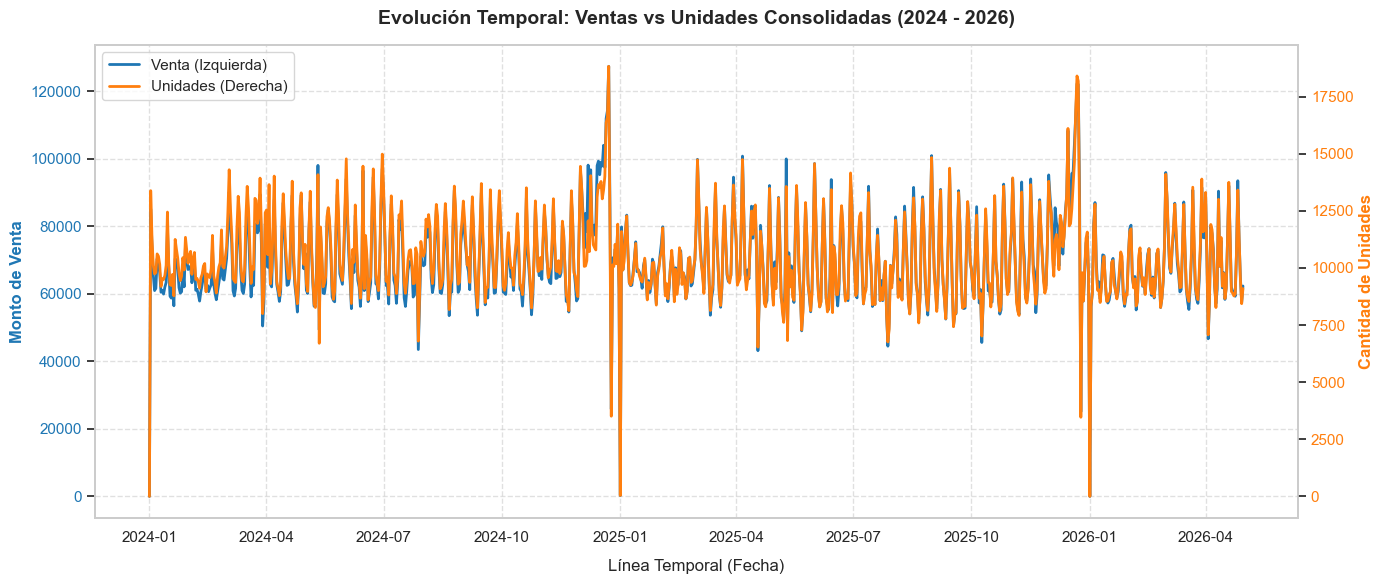

In [28]:
def graficar_serie_tiempo_doble_eje(df: pd.DataFrame):
    """
    Genera un gráfico de serie de tiempo con doble eje Y utilizando Seaborn.
    Asegura la conversión correcta de la columna de fechas para evitar solapamientos.
    """
    # Clonamos el DataFrame para evitar mutaciones inesperadas en la estructura original
    df_plot = df.copy()
    
    # Asegurar que el campo Fecha tenga el tipo datetime64 de forma vectorizada
    df_plot['Fecha'] = pd.to_datetime(df_plot['Fecha'])
    
    # 1. Configurar la figura base de Matplotlib
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Estilo estético global de Seaborn
    sns.set_theme(style="whitegrid")
    
    # 2. Primer Eje (Izquierdo): Venta
    color_venta = '#1f77b4'  # Azul corporativo estándar
    sns.lineplot(
        data=df_plot, 
        x='Fecha', 
        y='Venta', 
        ax=ax1, 
        color=color_venta, 
        linewidth=2, 
        label='Venta (Izquierda)'
    )
    
    # Configuración de etiquetas del primer eje
    ax1.set_xlabel('Línea Temporal (Fecha)', fontsize=12, labelpad=10)
    ax1.set_ylabel('Monto de Venta', color=color_venta, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_venta)
    ax1.grid(True, linestyle='--', alpha=0.6)  # Rejilla sutil solo para el eje primario
    
    # 3. Segundo Eje (Derecho): Unid
    # .twinx() crea un eje gemelo que comparte el mismo eje X
    ax2 = ax1.twinx()
    
    color_unid = '#ff7f0e'  # Naranja para contraste
    sns.lineplot(
        data=df_plot, 
        x='Fecha', 
        y='Unid', 
        ax=ax2, 
        color=color_unid, 
        linewidth=2, 
        label='Unidades (Derecha)'
    )
    
    # Configuración de etiquetas del segundo eje
    ax2.set_ylabel('Cantidad de Unidades', color=color_unid, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_unid)
    ax2.grid(False)  # Desactivar la rejilla secundaria para evitar contaminación visual
    
    # 4. Consolidar Leyendas en una sola caja
    # Al usar twinx, las leyendas se crean por separado; las unificamos manualmente
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, frameon=True)
    if ax2.get_legend(): 
        ax2.get_legend().remove() # Remover la leyenda duplicada del eje derecho
        
    # Título y ajustes de distribución
    plt.title('Evolución Temporal: Ventas vs Unidades Consolidadas (2024 - 2026)', fontsize=14, pad=15, fontweight='bold')
    fig.tight_layout()
    plt.show()

# Ejecución de la función pasando tu DataFrame 'dff'
graficar_serie_tiempo_doble_eje(dff)

In [44]:
dff["ratio"] = dff["Venta"]  / dff["Unid"] 
dff

,Fecha,Venta,Unid,ratio
0,2024-01-01,0.00,0.0,NaN
1,2024-01-02,85116.85,13379.0,6.361974
2,2024-01-03,74078.11,11290.0,6.561391
3,2024-01-04,65554.26,10105.0,6.487309
4,2024-01-05,60943.40,9736.0,6.259593
...,...,...,...,...
845,2026-04-26,93457.00,13408.0,6.970242
846,2026-04-27,76323.44,11372.0,6.711523
847,2026-04-28,64948.11,9544.0,6.805125
848,2026-04-29,57397.39,8435.0,6.804670


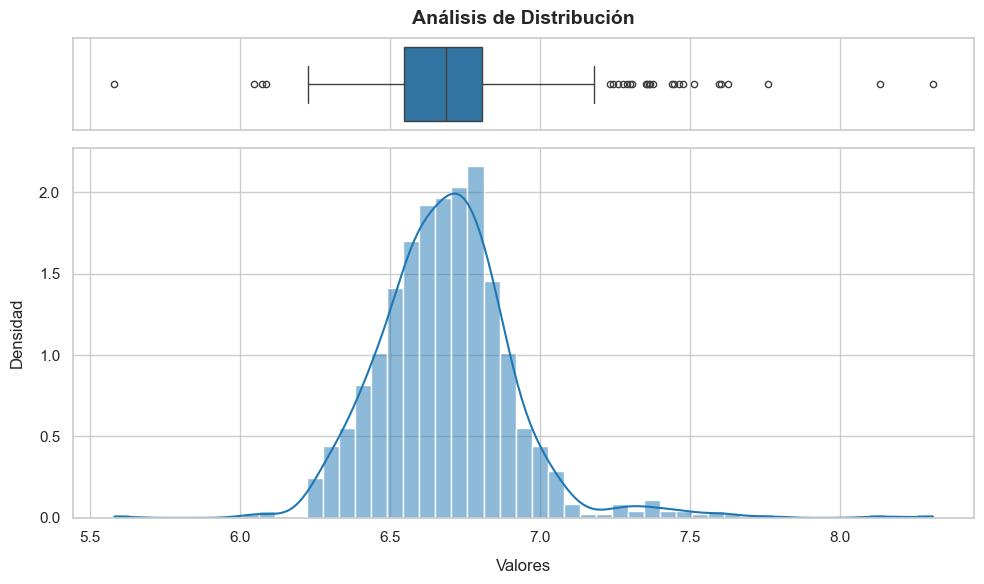

In [45]:
sns.set_theme(style="whitegrid")

fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, 
        sharex=True, 
        figsize=(10, 6), 
        gridspec_kw={"height_ratios": (0.2, 0.8)}
    )

sns.boxplot(
        data=dff, 
        x="ratio", 
        ax=ax_box, 
        color="#1f77b4", 
        fliersize=4.5
    )
ax_box.set(xlabel="")  # Remover etiqueta del eje X en el boxplot para evitar redundancia
ax_box.set_title(f"Análisis de Distribución", fontsize=14, pad=10, fontweight="bold")
    
    # 2. Histograma + Estimación de Densidad del Núcleo (KDE) (Subplot Inferior)
sns.histplot(
    data=dff, 
    x="ratio", 
    kde=True, 
    ax=ax_hist, 
    color="#1f77b4", 
    stat="density",  # Normaliza el histograma para que el área sea 1, compatible con KDE
    bins="auto"       # Selección óptima de bins basada en la regla de Freedman-Diaconis o Sturges
)

# Configuración avanzada de ejes y legibilidad
ax_hist.set_xlabel(f"Valores", fontsize=12, labelpad=10)
ax_hist.set_ylabel("Densidad", fontsize=12, labelpad=10)

# Optimización de márgenes para evitar truncamiento de etiquetas
plt.tight_layout()

plt.show()

In [46]:
df_clean = dff[['Venta', 'Unid']].dropna()
    
coeficiente_pearson = df_clean['Venta'].corr(df_clean['Unid'], method='pearson')
coeficiente_pearson

np.float64(0.9801193194164767)

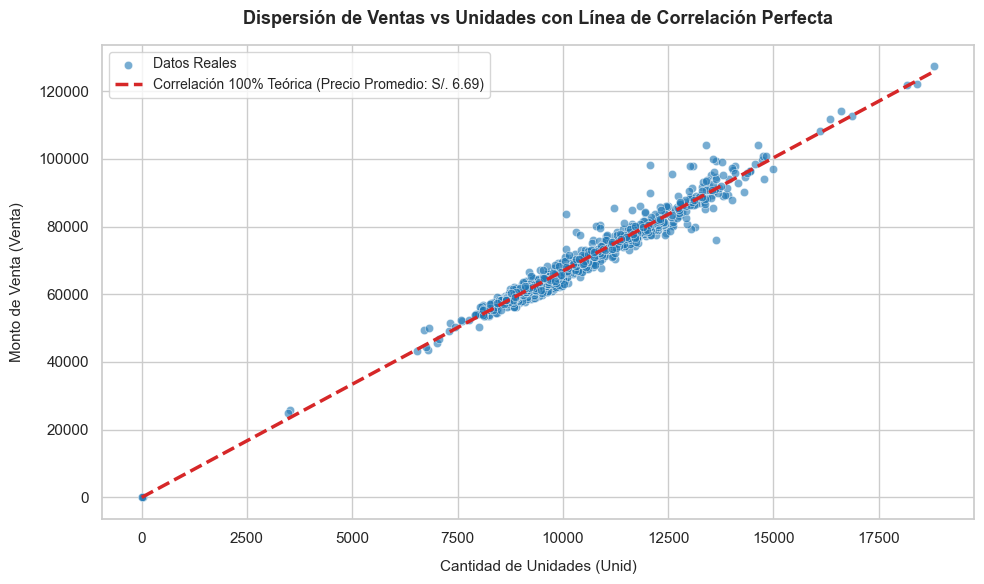

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_dispersion_con_referencia(df: pd.DataFrame):
    df_clean = df[['Venta', 'Unid']].dropna()
    
    # Calcular el precio promedio global de forma vectorizada (pendiente m)
    precio_promedio = df_clean['Venta'].sum() / df_clean['Unid'].sum()
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # 1. Gráfico de dispersión para los datos reales
    sns.scatterplot(
        data=df_clean,
        x='Unid',
        y='Venta',
        alpha=0.6,
        color='#1f77b4',
        edgecolor='w',
        label='Datos Reales'
    )
    
    # 2. Construcción vectorizada de la línea de correlación 100% teórica
    x_valores = np.array([df_clean['Unid'].min(), df_clean['Unid'].max()])
    y_valores = precio_promedio * x_valores
    
    # 3. Trazar la línea de referencia en rojo
    plt.plot(
        x_valores, 
        y_valores, 
        color='#d62728', 
        linestyle='--', 
        linewidth=2.5, 
        label=f'Correlación 100% Teórica (Precio Promedio: S/. {precio_promedio:.2f})'
    )
    
    plt.title("Dispersión de Ventas vs Unidades con Línea de Correlación Perfecta", fontsize=13, pad=15, fontweight='bold')
    plt.xlabel("Cantidad de Unidades (Unid)", fontsize=11, labelpad=10)
    plt.ylabel("Monto de Venta (Venta)", fontsize=11, labelpad=10)
    plt.legend(loc='upper left', fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.show()

graficar_dispersion_con_referencia(dff)

In [54]:
dff["ds"] = pd.to_datetime(dff["Fecha"]).dt.date
dff["y"] = dff["Venta"]
dff

,Fecha,Venta,Unid,ratio,ds,y
0,2024-01-01,0.00,0.0,NaN,2024-01-01,0.00
1,2024-01-02,85116.85,13379.0,6.361974,2024-01-02,85116.85
2,2024-01-03,74078.11,11290.0,6.561391,2024-01-03,74078.11
3,2024-01-04,65554.26,10105.0,6.487309,2024-01-04,65554.26
4,2024-01-05,60943.40,9736.0,6.259593,2024-01-05,60943.40
...,...,...,...,...,...,...
845,2026-04-26,93457.00,13408.0,6.970242,2026-04-26,93457.00
846,2026-04-27,76323.44,11372.0,6.711523,2026-04-27,76323.44
847,2026-04-28,64948.11,9544.0,6.805125,2026-04-28,64948.11
848,2026-04-29,57397.39,8435.0,6.804670,2026-04-29,57397.39


In [56]:
dff["ds"] = pd.to_datetime(dff["Fecha"])

# 2. Filtrado vectorial directo (Pandas parsea el string internamente en C)
dfff_train = dff[dff["ds"] < "2026-01-01"][["ds", "y"]]

In [60]:
from prophet import Prophet

d:\Usuarios\SP44812227\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [61]:
model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
model.fit(dfff_train)

12:40:03 - cmdstanpy - INFO - Chain [1] start processing
12:40:03 - cmdstanpy - INFO - Chain [1] done processing


In [62]:
future = model.make_future_dataframe(periods=30, freq='D')

In [63]:
forecast = model.predict(future)

In [67]:
dff

,Fecha,Venta,Unid,ratio,ds,y
0,2024-01-01,0.00,0.0,NaN,2024-01-01,0.00
1,2024-01-02,85116.85,13379.0,6.361974,2024-01-02,85116.85
2,2024-01-03,74078.11,11290.0,6.561391,2024-01-03,74078.11
3,2024-01-04,65554.26,10105.0,6.487309,2024-01-04,65554.26
4,2024-01-05,60943.40,9736.0,6.259593,2024-01-05,60943.40
...,...,...,...,...,...,...
845,2026-04-26,93457.00,13408.0,6.970242,2026-04-26,93457.00
846,2026-04-27,76323.44,11372.0,6.711523,2026-04-27,76323.44
847,2026-04-28,64948.11,9544.0,6.805125,2026-04-28,64948.11
848,2026-04-29,57397.39,8435.0,6.804670,2026-04-29,57397.39


In [ ]:
forecast1 = forecast[["ds", "trend", "weekly", "yearly", "yhat"]].merge(dff[["ds", "y"]], on="ds", how="left")

In [35]:
carpeta_fact = "fact"
patron_archivos = os.path.join(carpeta_fact, "Vta*.xlsx")
archivos_excel = glob(patron_archivos)

df_venta = pd.concat([pd.read_excel(archivo) for archivo in archivos_excel], ignore_index=True )
dim_area = pd.read_excel(r"dim\dim_areas.xlsx")
dim_calendar = pd.read_excel(r"dim\dim_calendar_final.xlsx")



In [36]:
cols = dim_calendar.columns.drop("Fecha")


In [43]:
df_venta_01 = df_venta.groupby(["DivArea", "Codigo Local", "Fecha"]).agg(Venta=("_VtaNeta", "sum")).reset_index()

In [44]:
df_venta_01["llave"] = df_venta_01["Codigo Local"] + "-" + df_venta_01["DivArea"]

df_venta_02 = df_venta_01.merge(dim_calendar, on="Fecha", how="left")
df_venta_03 = df_venta_02.fillna(0)
df_venta_03[cols] = df_venta_03[cols].astype(int)

In [45]:
columnas_a_renombrar = {
    "Fecha": "ds",
    "Venta": "y",
}

# Aplicar el cambio in-place para modificar los metadatos directamente en memoria sin duplicar el DataFrame
df_venta_03.rename(columns=columnas_a_renombrar, inplace=True)

df_venta_03

,DivArea,Codigo Local,ds,y,llave,black_friday,dia_de_la_madre,dia_del_padre,efecto_fin_mes,efecto_quincena,fiestas_patrias,halloween,navidad,nuevo_año,post_año_nuevo,post_navidad,pre_navidad,pre_nuevo_año,san_valentin,semana_santa
0,D1A01,1198,2024-01-01,0.00,1198-D1A01,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,D1A01,1198,2024-01-02,16494.47,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,D1A01,1198,2024-01-03,12344.29,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,D1A01,1198,2024-01-04,12596.64,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,D1A01,1198,2024-01-05,12533.60,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1400659,D4A14,X210,2026-04-26,77.84,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1400660,D4A14,X210,2026-04-27,53.20,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1400661,D4A14,X210,2026-04-28,61.48,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1400662,D4A14,X210,2026-04-29,32.39,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [50]:
df_venta_03.to_parquet("files/fact_ventas_predict.parquet")